In [271]:
import matplotlib.pyplot as plt
import math

In [3]:
x = 2
y = 5

w = 1
b = 1

o = w * x + b

print(o)


3


In [4]:
error = y - o

print(error)

2


In [5]:
error_sqr = (y - o) ** 2

print(error_sqr)

4


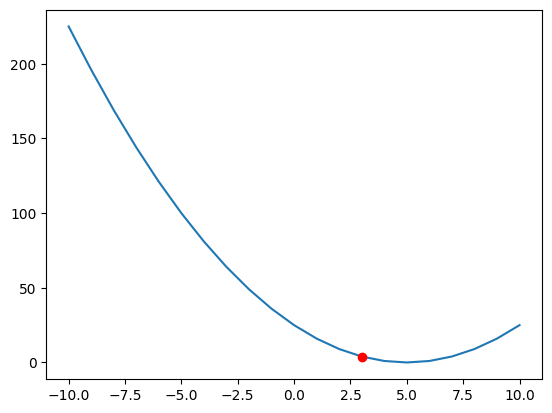

In [6]:
e = []
for i in range(-10, 11):
    e.append((y - i) ** 2)

plt.plot(range(-10, 11), e, zorder=1)
plt.scatter(o, error_sqr, color='red', zorder=2)

plt.show()

error(y, o) = (y - o) ** 2

-2y + 2o

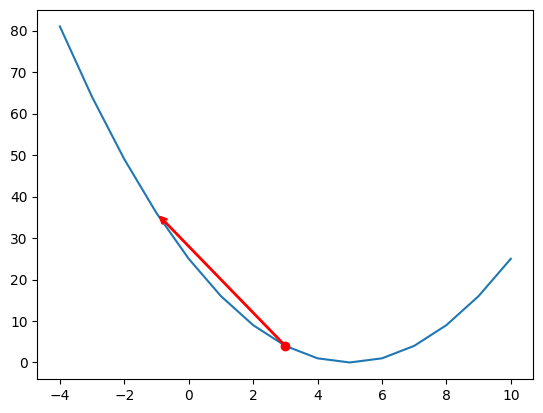

In [7]:
dx = -2 * y + 2 * o

e = []
for i in range(-4, 11):
    e.append((y - i) ** 2)

plt.plot(range(-4, 11), e, zorder=1)
plt.scatter(o, error_sqr, color='red', zorder=2)

plt.annotate(
    "",
    xy=(o + dx, (y - (o + dx)) ** 2),      # arrow tip
    xytext=(o, error_sqr),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='red'),
)

plt.show()

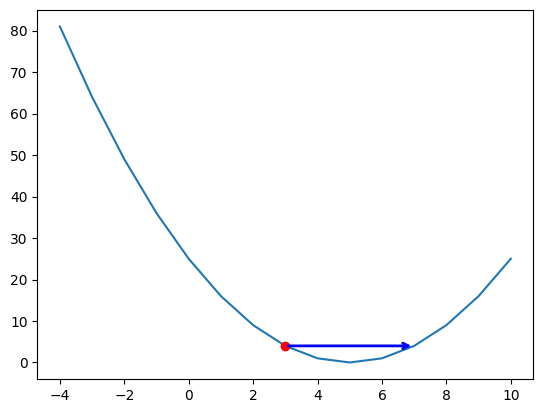

In [8]:
dx = -2 * y + 2 * o

e = []
for i in range(-4, 11):
    e.append((y - i) ** 2)

plt.plot(range(-4, 11), e, zorder=1)
plt.scatter(o, error_sqr, color='red', zorder=2)

plt.annotate(
    "",
    xy=(o - dx, (y - (o - dx)) ** 2),      # arrow tip
    xytext=(o, error_sqr),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='blue'),
)

plt.show()

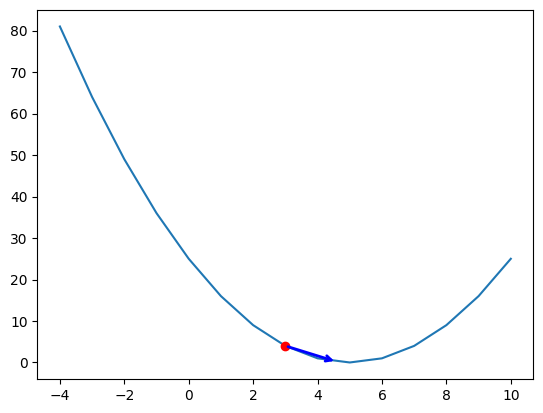

In [9]:
dx = -2 * y + 2 * o
a = 0.4
dx = a * dx
e = []
for i in range(-4, 11):
    e.append((y - i) ** 2)

plt.plot(range(-4, 11), e, zorder=1)
plt.scatter(o, error_sqr, color='red', zorder=2)

plt.annotate(
    "",
    xy=(o - dx, (y - (o - dx)) ** 2),      # arrow tip
    xytext=(o, error_sqr),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='blue'),
)

plt.show()

o = w * x + b
loss = (y - o) ** 2

dw = 2(y - o) * d(y - o)

dw = -2xy + 2ox

db = 2(y - o) * d(y - o)

db = -2y + 2o

In [10]:
dw = -2 * x * y + 2 * o * x
db = -2 * y + 2 * o
a = 0.01
w -= a * dw
b -= a * db

o = w * x + b
print(o)



3.2


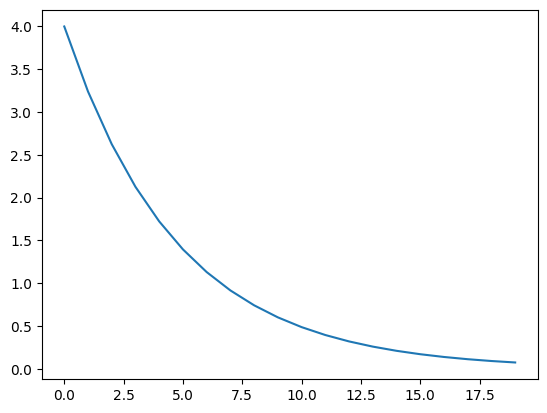

In [11]:
x = 2
y = 5

w = 1
b = 1

a = 0.01
lh = []
for _ in range(20):
    o = w * x + b
    error_sqr = (y - o) ** 2
    lh.append(error_sqr)

    dw = -2 * x * y + 2 * o * x
    db = -2 * y + 2 * o

    w -= a * dw
    b -= a * db


plt.plot(lh)
plt.show()

In [12]:
print(w * x + b)

4.756846690818861


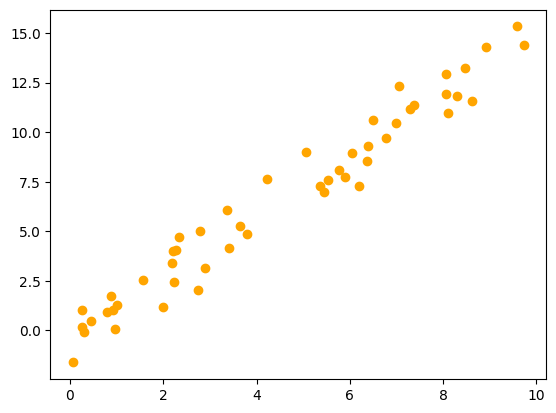

In [273]:
import random

random.seed(42)

sx = [random.random() * 10 for _ in range(50)]
sy = [random.normalvariate() for _ in range(50)]
sy = [1.5 * x + y for x, y in zip(sx, sy)]

plt.scatter(sx, sy, color='orange', zorder=2)
plt.show()

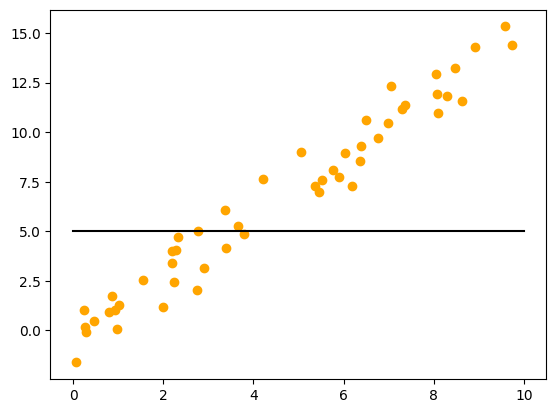

In [274]:

w1 = 0
b = 5
line = []

for i in range(11):
    o = w1 * i + b
    line.append(o)


plt.scatter(sx, sy, color='orange', zorder=1)
plt.plot(range(11), line, color='black', zorder=2)
plt.show()



1.4536491877092856 0.1771788324584528


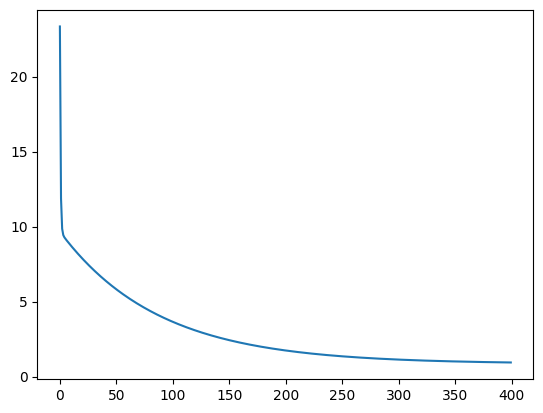

In [275]:
a = 0.01

w1 = 0
b = 5

lh = []
for _ in range(400):
    gw = 0
    gb = 0
    el = []
    for x1, y1 in zip(sx, sy):
        o = w1 * x1 + b
        error_sqr = (y1 - o) ** 2
        el.append(error_sqr)

        gw += -2 * x1 * y1 + 2 * o * x1
        gb += -2 * y1 + 2 * o


    w1 -= a * gw / len(sx)
    b -= a * gb / len(sx)

    lh.append(sum(el) / len(el))

print(w1, b)
plt.plot(lh)
plt.show()

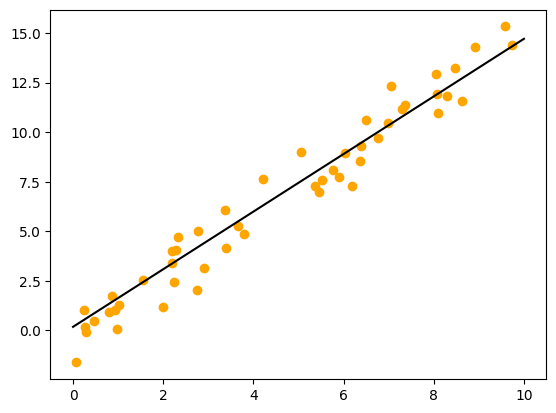

In [276]:
line = []
for i in range(11):
    o = w1 * i + b
    line.append(o)

plt.scatter(sx, sy, color='orange', zorder=1)
plt.plot(range(11), line, color='black', zorder=2)
plt.show()

o = w1x1 + w2x2 + b

(y - o) ** 2

2(y - o) * (y - (w1x1 + w2x2 + b))

-2x1 * (y - o)

In [17]:
class Perceptron:
    def __init__(self):
        self.w1 = 0
        self.w2 = 0
        self.b = 0

    def forward(self, x1, x2):
        return self.w1 * x1 + self.w2 * x2 + self.b

    def backward(self, x1, x2, y, o):
        dw1 = -2 * x1 * (y - o)
        dw2 = -2 * x2 * (y - o)
        db = -2 * (y - o)
        return dw1, dw2, db

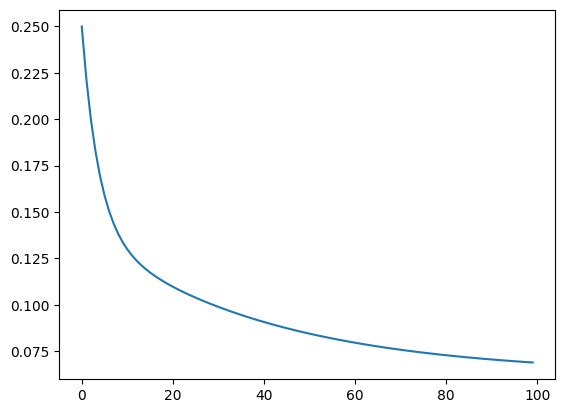

In [18]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [0, 0, 0, 1]

a = 0.01

perceptron = Perceptron()

lh = []
for _ in range(100):
    gw1 = 0
    gw2 = 0
    gb = 0
    el = []
    for (x1, x2), y1 in zip(x, y):
        o = perceptron.forward(x1, x2)
        error_sqr = (y1 - o) ** 2
        el.append(error_sqr)

        dw1, dw2, db = perceptron.backward(x1, x2, y1, o)

        gw1 += dw1
        gw2 += dw2
        gb += db

    lh.append(sum(el) / len(el))
    perceptron.w1 -= a * gw1
    perceptron.w2 -= a * gw2
    perceptron.b -= a * gb

plt.plot(lh)
plt.show()

In [19]:
for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

0 0 -> -0.1224
0 1 -> 0.2700
1 0 -> 0.2700
1 1 -> 0.6624


In [20]:
def sigmoid(x):
    return 1 / (1 + math.exp(-x))


o = sigmoid(w1x1 + w2x2 + b)
e = (y - o) ** 2

dw1 = 2(y - o) * d(y - o)
dw1 = 2(y - o) * (0 - sigmoid(w1x1 + w2x2 + b)')


sigmoid(x) = 1 / (1 + exp(-x))

o = sigmoid(w1x1 + w2x2 + b)


$$ \frac{1}{1 + e^{-x}}$$

$$ \frac{ e^{-x} }{(1 + e^{-x}) (1 + e^{-x}) }  $$

$$ \frac{ 1 }{(1 + e^{-x}) } \cdot \frac{ e^{-x} }{(1 + e^{-x}) }  $$

$$ \frac{ 1 }{(1 + e^{-x}) } \cdot \frac{ 1 + e^{-x} -1 }{(1 + e^{-x}) }  $$

$$ \frac{ 1 }{(1 + e^{-x}) } \cdot \frac{ (1 + e^{-x}) -1 }{(1 + e^{-x}) }  $$

$$ \frac{ 1 }{(1 + e^{-x}) } \cdot \frac{ 1 + e^{-x} }{(1 + e^{-x}) } - \frac{ 1 }{(1 + e^{-x}) }  $$

$$ \frac{ 1 }{(1 + e^{-x}) } \cdot 1 - \frac{ 1 }{(1 + e^{-x}) }  $$

$$ sig(x) \cdot (1 - sig(x)) $$


dw1 = 2(y - o) * (0 - sigmoid(w1x1 + w2x2 + b)')

dw1 = 2(y - o) * (0 - sigmoid(w1x1 + w2x2 + b) * (1 - sigmoid(w1x1 + w2x2 + b)) * (w1x1 + w2x2 + b)')

dw1 = 2(y - o) * (0 - o * (1 - o) * (w1x1 + w2x2 + b)')

dw1 = 2(y - o) * (- o * (1 - o) * x1)
dw2 = 2(y - o) * (- o * (1 - o) * x2)
db = 2(y - o) * (- o * (1 - o)))

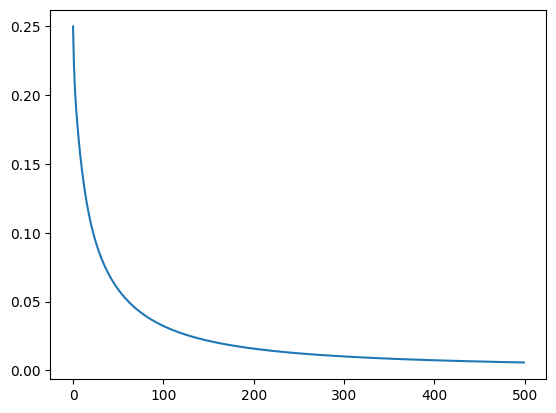

In [21]:
class Perceptron:
    def __init__(self):
        self.w1 = 0
        self.w2 = 0
        self.b = 0

    def forward(self, x1, x2):
        h = self.w1 * x1 + self.w2 * x2 + self.b
        return sigmoid(h)

    def backward(self, x1, x2, y, o):
        dw1 = 2 * (y - o) * (- o * (1 - o) * x1)
        dw2 = 2 * (y - o) * (- o * (1 - o) * x2)
        db = 2 * (y - o) * (- o * (1 - o))
        return dw1, dw2, db



x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [0, 0, 0, 1]

a = 0.5

perceptron = Perceptron()

def train(perceptron, x, y, a, epochs):

    lh = []
    for _ in range(epochs):
        gw1 = 0
        gw2 = 0
        gb = 0
        el = []
        for (x1, x2), y1 in zip(x, y):
            o = perceptron.forward(x1, x2)
            error_sqr = (y1 - o) ** 2
            el.append(error_sqr)

            dw1, dw2, db = perceptron.backward(x1, x2, y1, o)

            gw1 += dw1
            gw2 += dw2
            gb += db

        lh.append(sum(el) / len(el))
        perceptron.w1 -= a * gw1
        perceptron.w2 -= a * gw2
        perceptron.b -= a * gb

    plt.plot(lh)
    plt.show()

train(perceptron, x, y, a, 500)

In [22]:
print(perceptron.w1, perceptron.w2, perceptron.b)

for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

4.646713304738053 4.646713304738053 -7.067441931349508
0 0 -> 0.0009
0 1 -> 0.0816
1 0 -> 0.0816
1 1 -> 0.9026


In [23]:
# plot regions 3d


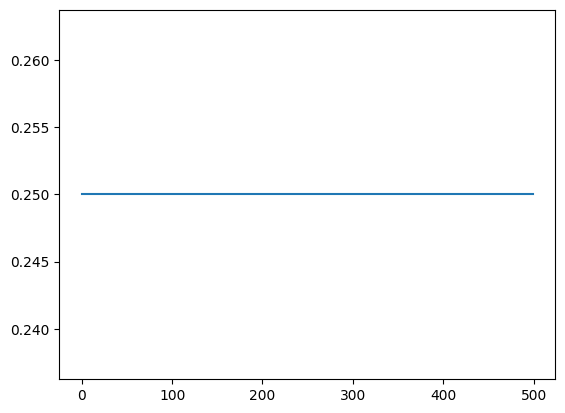

In [24]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [0, 1, 1, 0]

a = 0.5

perceptron = Perceptron()

train(perceptron, x, y, a, 500)

In [25]:
print(perceptron.w1, perceptron.w2, perceptron.b)

for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

0.0 0.0 0.0
0 0 -> 0.5000
0 1 -> 0.5000
1 0 -> 0.5000
1 1 -> 0.5000


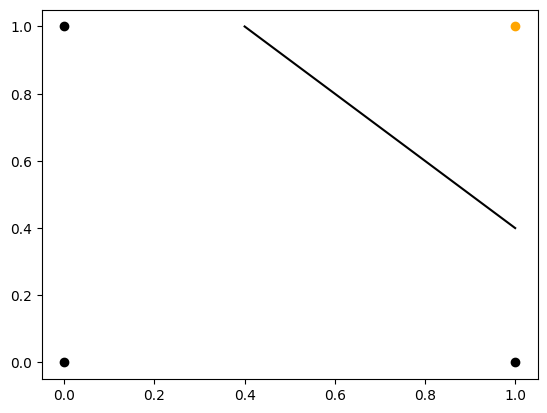

In [26]:
plt.scatter([0, 0, 1], [0, 1, 0], color='black', zorder=1)
plt.scatter([1], [1], color='orange', zorder=1)
plt.plot([0.4, 1], [1, 0.4], color='black', zorder=2)
plt.show()

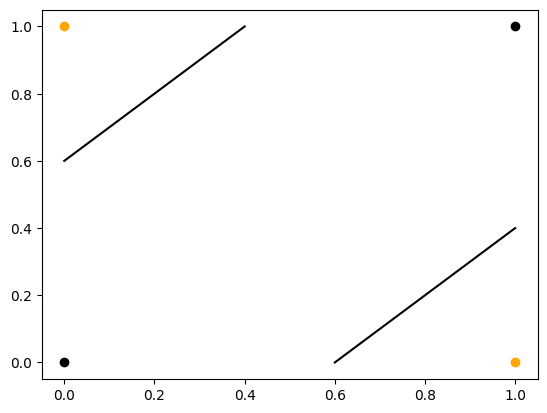

In [27]:
plt.scatter([0, 1], [0, 1], color='black', zorder=1)
plt.scatter([0, 1], [1, 0], color='orange', zorder=1)

plt.plot([0.0, 0.4], [0.6, 1.0], color='black', zorder=2)
plt.plot([0.6, 1], [0.0, 0.4], color='black', zorder=2)

plt.show()

In [28]:
x1 = [0, 1]
w1 = [1, 1]

b = [0]

o = [w1[0] * x1[0] + w1[1] * x1[1] + b[0]]
print(o)

[1]


In [29]:
# 1 x 2
x1 = [[0, 1]]

# 2 x 1
w1 = [[1],
      [1]]


def matmul(a, b):
    mat = [[0 for _ in range(len(b[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(b[0])):
            for k in range(len(a[0])):
                mat[i][j] += a[i][k] * b[k][j]

    return mat

print(matmul(x1, w1))

[[1]]


In [30]:

b = [[1]]

o = matmul(x1, w1)

def add(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] + b[i][j]

    return mat

print(add(o, b))

[[2]]


In [183]:
class Linear:

    def __init__(self, inp, out):
        self.w = [[0 for _ in range(out)] for _ in range(inp)]
        self.b = [[0 for _ in range(out)]]

    def forward(self, x):
        return add(matmul(x, self.w), self.b)



x1 = [[0, 1]]
linear = Linear(2, 1)
print(linear.forward(x1))

[[1.0]]


In [32]:
linear1 = Linear(2, 1)
linear2 = Linear(2, 1)

x1 = [[0, 1]]

h1 = linear1.forward(x1)
h2 = linear2.forward(x1)

print(h1, h2)

[[0]] [[0]]


In [33]:
linear1 = Linear(2, 2)

h1 = linear1.forward(x1)

print(h1)

[[0, 0]]


In [34]:
linear2 = Linear(2, 1)

h2 = linear2.forward(h1)

print(h2)

[[0]]


A linear transformation inside a linear transformation is still a linear transformation.

In [35]:
def sigmoid(x):
    mat = [[0 for _ in range(len(x[0]))] for _ in range(len(x))]

    for i in range(len(x)):
        for j in range(len(x[0])):
            mat[i][j] = 1 / (1 + math.exp(-x[i][j]))

    return mat

linear1 = Linear(2, 2)
linear2 = Linear(2, 1)

h1 = sigmoid(linear1.forward(x1))
h2 = sigmoid(linear2.forward(h1))

print(h2)

[[0.5]]


In [260]:
class Linear:

    def __init__(self, inp, out):
        self.w = [[0 for _ in range(out)] for _ in range(inp)]
        self.b = [[0 for _ in range(out)]]

    def forward(self, x):
        m = matmul(x, self.w)
        # broadcasting
        bb = [self.b[0] for _ in range(len(m))]
        return add(m, bb)

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

linear = Linear(2, 2)
h1 = linear.forward(x)
print(h1)

h1 = linear(x)
print(h1)

[[0, 0], [0, 0], [0, 0], [0, 0]]
[[0, 0], [0, 0], [0, 0], [0, 0]]


In [261]:
def sub(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] - b[i][j]

    return mat

def pow(a, n):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] ** n

    return mat

def mul_s(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] * b

    return mat

def mul(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] * b[i][j]

    return mat

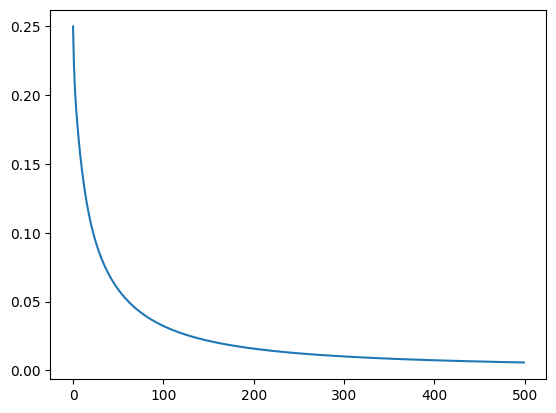

In [262]:
class Perceptron:

    def __init__(self, inp, out):
        self.linear1 = Linear(inp, out)

    def forward(self, x):
        h1 = sigmoid(self.linear1(x))
        return h1

    def backward(self, x, y):
        l1 = self.linear1(x)
        o = sigmoid(l1)

        de = mul_s(sub(y, o), 2)
        do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

        db = mul(de, do)

        dw = mul([q * len(x[0]) for q in db], x)

        return [[sum([q[i] for q in dw])] for i in range(len(dw[0]))], [[sum([q[0] for q in db])]]

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)


x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [[0], [0], [0], [1]]

a = 0.5

perceptron = Perceptron(2, 1)

def train(perceptron, x, y, a, epochs):

    lh = []
    for _ in range(epochs):

        o = perceptron(x)

        error_sqr = sum(q[0] for q in pow(sub(y, o), 2)) / len(y)

        lh.append(error_sqr)

        dw, db = perceptron.backward(x, y)

        perceptron.linear1.w = sub(perceptron.linear1.w, mul_s(dw, a))
        perceptron.linear1.b = sub(perceptron.linear1.b, mul_s(db, a))

    plt.plot(lh)
    plt.show()

train(perceptron, x, y, a, 500)

In [263]:
print(perceptron.linear1.w, perceptron.linear1.b)

for x1, y1 in zip(x, y):
    o = perceptron([x1])
    print(f'{x1} -> {o[0]}')

[[4.646713304738055], [4.646713304738055]] [[-7.067441931349512]]
(0, 0) -> [0.0008516848626281008]
(0, 1) -> [0.08160563105078451]
(1, 0) -> [0.08160563105078451]
(1, 1) -> [0.902558796204585]


In [264]:
class MLP:

    def __init__(self, inp, out):
        self.linear1 = Linear(inp, 4)
        self.linear2 = Linear(4, out)

    def forward(self, x):
        h1 = sigmoid(self.linear1(x))
        return sigmoid(self.linear2(h1))

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)


mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

o = mlp(x)

print(o)

[[0.5], [0.5], [0.5], [0.5]]


h1 = sig(w1x1 + w2x2 + b1)

h2 = sig(w3x1 + w4x2 + b2)

o = sig(w5h1 + w6h2 + b3)

e = (y - o) ** 2

dw1 = 2(y - o) * d(y - o)

n1 = w5h1 + w6h2 + b3

d(y - o) = 0 - sig(n1)'

d(y - o) = 0 - (sig(n1) * (1 - sig(n1)) * n1'))

n1 = w5h1 + w6h2 + b3

dw5 = 2(y - o) * (0 - sig(n1) * (1 - sig(n1)) * (w5h1 + w6h2 + b3)')

dw5 = 2(y - o) * (0 - sig(n1) * (1 - sig(n1)) * h1)

dw6 = 2(y - o) * (0 - sig(n1) * (1 - sig(n1)) * h2)

db3 = 2(y - o) * (0 - sig(n1) * (1 - sig(n1)))

n2 = w1x1 + w2x2 + b1

dw1 = 2(y - o) * (0 - sig(n1) * (1 - sig(n1)) * (w5 (sig(n2)) + w6h2 + b3))

dw1 = 2(y - o) * (0 - sig(n1) * (1 - sig(n1)) * (w5 (sig(n2) * (1 - sig(n2) * (w1x1 + w2x2 + b1)')))

dw1 = 2(y - o) * (0 - sig(n1) * (1 - sig(n1)) * (w5 (sig(n2) * (1 - sig(n2) * x1 )))



In [265]:


def backward(self, x, y):
    l1 = self.linear1(x)
    h1 = sigmoid(l1)
    l2 = self.linear2(h1)
    o = sigmoid(l2)

    de = mul_s(sub(y, o), 2)

    do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

    db2 = mul(de, do)

    dw2 = mul([q * len(h1[0]) for q in db2], h1)

    dl2 = mul([q * len(self.linear2.w) for q in db2], [[q[0] for q in self.linear2.w] for _ in db2])

    db1 = mul(dl2, mul(h1, sub([[1] * len(h1[0]) for _ in h1], h1)))

    bd1 = [[q] * len(x[0]) for q in db1]

    bx = [[[w] * len(bd1[0][0]) for w in q] for q in x]

    dw1 = [mul(q, w) for q, w in zip(bd1, bx)]

    gb2 = [[sum(q[0] for q in db2)]]
    gw2 = [[sum([d[i] for d in dw2])] for i in range(len(dw2[0]))]
    gb1 = [[sum([d[i] for d in db1]) for i in range(len(db1[0]))]]
    gw1 = [[sum(e[q][j] for e in dw1) for j in range(len(dw1[0][0]))] for q in range(len(dw1[0]))]


    return gw1, gb1, gw2, gb2

mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

backward(mlp, x, y)
MLP.backward = backward

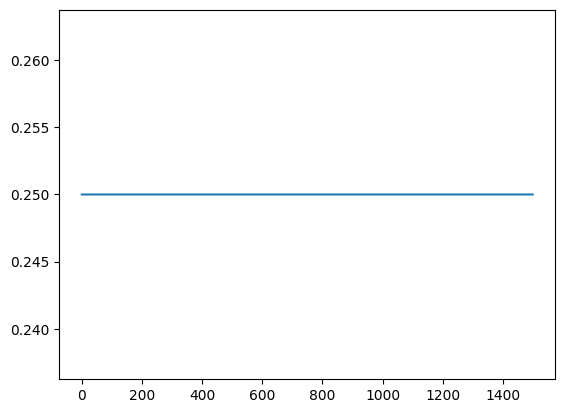

In [266]:
def train(model, x, y, a, epochs):

    lh = []
    for _ in range(epochs):

        o = model(x)
        lh.append(sum([x[0] for x in pow(sub(y, o), 2)]) / len(y))

        jw1, jb1, jw2, jb2 = model.backward(x, y)

        model.linear2.b = sub(model.linear2.b, mul_s(jb2, a))
        model.linear2.w = sub(model.linear2.w, mul_s(jw2, a))
        model.linear1.b = sub(model.linear1.b, mul_s(jb1, a))
        model.linear1.w = sub(model.linear1.w, mul_s(jw1, a))

    plt.plot(lh)
    plt.show()


mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

train(mlp, x, y, 0.1, 1500)

In [267]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.5]
[0, 1] -> [0.5]
[1, 0] -> [0.5]
[1, 1] -> [0.5]


In [268]:
jw1, jb1, jw2, jb2 = mlp.backward(x, y)

print(jw1, jb1, jw2, jb2)

[[0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0]] [[0.0, 0.0, 0.0, 0.0]] [[0.0], [0.0], [0.0], [0.0]] [[0.0]]


In [269]:
de = mul_s(sub(y, o), 2)

do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

db2 = mul(de, do)

print(db2)

[[0.25], [-0.25], [-0.25], [0.25]]


In [278]:
class Linear:

    def __init__(self, inp, out):
        self.w = [[random.random() for _ in range(out)] for _ in range(inp)]
        self.b = [[random.random() for _ in range(out)]]

    def forward(self, x):
        m = matmul(x, self.w)
        # broadcasting
        bb = [self.b[0] for _ in range(len(m))]
        return add(m, bb)

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

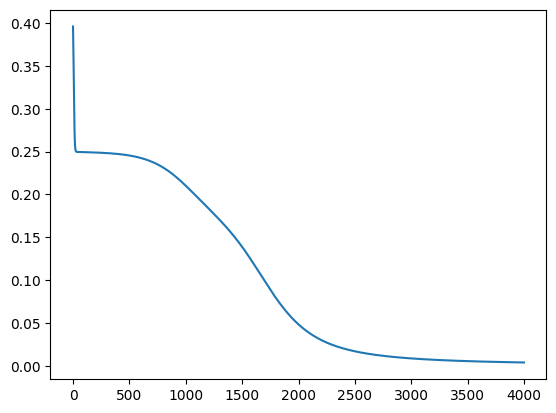

In [283]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

train(mlp, x, y, 0.1, 4000)

In [284]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.05582848137791721]
[0, 1] -> [0.9285941506839214]
[1, 0] -> [0.9490737154200855]
[1, 1] -> [0.06837599941237864]
